In [1]:
import sys
sys.path.append("../")

from brian2 import *
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *
from functions import *


In [ ]:

"""- - - - MAIN SIMULATION - - - - """

T = 2000 # ms
N_trials = 100
N_spikes = 40
spike_delay = 4*ms

# normal distribution parameters
min_rand = 0*ms
max_rand = 10*ms

counts = np.zeros(N_trials)

spike_delays = []

for i in tqdm(range(N_trials)):
    # 1. Setup Input (Presynaptic Neuron)
    # Let's say it fires at 20Hz
    #P = PoissonGroup(1, 20*Hz)
    idx = np.zeros(N_spikes)
    spike_times = np.linspace(10, 3*T/4, N_spikes)*ms
    ms_per_spike = (T/2 - 10)/N_spikes
    firing_frequency = 1000/ms_per_spike
    #print(f"FF: {firing_frequency}")
    P = SpikeGeneratorGroup(1, idx, spike_times)


    # 2. The Uniform delay Generator Group
    UniformGen = NeuronGroup(1, 
        '''
        scheduled_time : second
        is_active : boolean
        ''',
        threshold = 'is_active and t >= scheduled_time',
        reset = 'is_active = False',
        method = 'euler')

    # 3. Connect Pre-synapse to the Generator
    # Each spike from P increases the firing rate of PoissonGen
    S_in = Synapses(P, UniformGen, on_pre='''
                    is_active = True
                    scheduled_time = t + (min_rand + rand()*(max_rand - min_rand))
                    ''')
    S_in.connect()

    # 4. Connect Generator to Post-synaptic Target
    Post = NeuronGroup(1, 'dv/dt = -v/(10*ms) : 1', threshold='v>1', reset='v=0')
    S_out = Synapses(UniformGen, Post, on_pre='v_post += 0.3')
    S_out.connect()


    # Monitors
    mon_p = SpikeMonitor(P)
    mon_gen = SpikeMonitor(UniformGen)
    mon_post = StateMonitor(Post, 'v', record = True)
    spikemon_post = SpikeMonitor(Post, record = True)

    
    run(T*ms)


    spk_trn = mon_gen.spike_trains()[0]
    counts[i] = len(spk_trn)


    for spike in spk_trn:
        #print(spike)
        delay = spike - spike_times[spike_times < spike][-1]    #last spike before the poisson spike
        #print(delay)
        spike_delays.append(delay*1000)


  0%|          | 0/100 [00:00<?, ?it/s]INFO       No numerical integration method specified for group 'neurongroup_1', using method 'exact' (took 0.04s). [brian2.stateupdaters.base.method_choice]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. 2 lines of abstract code, first line is: 'is_active = True'
 [brian2.codegen.generators.base]
  1%|          | 1/100 [00:01<02:51,  1.73s/it]INFO       No numerical integration method specified for group 'neurongroup_3', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. 2 lines of abstract code, first line is: 'is_active = True'
 [brian2.codeg

[0.01       0.0478481  0.0856962  0.1235443  0.16139241 0.19924051
 0.23708861 0.27493671 0.31278481 0.35063291 0.38848101 0.42632911
 0.46417722 0.50202532 0.53987342 0.57772152 0.61556962 0.65341772
 0.69126582 0.72911392 0.76696203 0.80481013 0.84265823 0.88050633
 0.91835443 0.95620253 0.99405063 1.03189873 1.06974684 1.10759494
 1.14544304 1.18329114 1.22113924 1.25898734 1.29683544 1.33468354
 1.37253165 1.41037975 1.44822785 1.48607595 1.52392405 1.56177215
 1.59962025 1.63746835 1.67531646 1.71316456 1.75101266 1.78886076
 1.82670886 1.86455696 1.90240506 1.94025316 1.97810127 2.01594937
 2.05379747 2.09164557 2.12949367 2.16734177 2.20518987 2.24303797
 2.28088608 2.31873418 2.35658228 2.39443038 2.43227848 2.47012658
 2.50797468 2.54582278 2.58367089 2.62151899 2.65936709 2.69721519
 2.73506329 2.77291139 2.81075949 2.84860759 2.8864557  2.9243038
 2.9621519  3.        ] s
[  10.           47.84810127   85.69620253  123.5443038   161.39240506
  199.24050633  237.08860759  274

Text(0, 0.5, 'v [mV]')

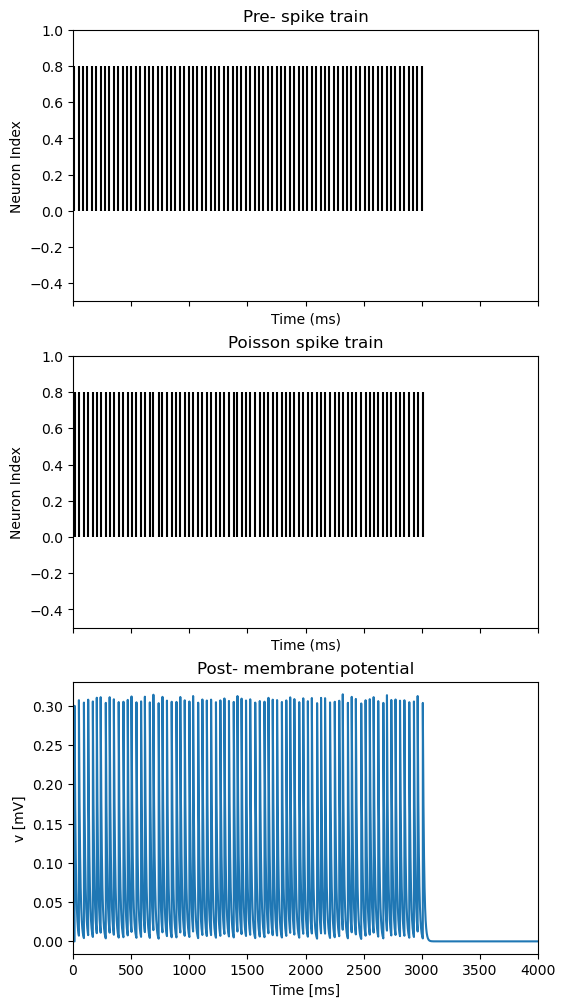

In [3]:
fig, ax = plt.subplots(3, 1, figsize = (6, 12), sharex = True)

print(spike_times)

plot_raster(np.array([spike_times/ms]), T, ax = ax[0])
ax[0].set_title("Pre- spike train")

plot_raster(np.array([spk_trn/ms]), T, ax = ax[1])
ax[1].set_title("Poisson spike train")

ax[2].plot(mon_post.t/ms, mon_post.v[0])
ax[2].set_title("Post- membrane potential")
ax[2].set_xlabel("Time [ms]")
ax[2].set_ylabel("v [mV]")

In [4]:
# Visualization of the frequency transformation
print(f"DEFAULT DT: {defaultclock.dt*ms}")


avg_poiss = np.mean(counts)
std_poiss = np.std(counts)
print(f"Mean: {avg_poiss}")
print(f"STD: {std_poiss}")
print(f"Mean Ratio = {avg_poiss/N_spikes}")
print(f"STD Ratio = {std_poiss/N_spikes}")



DEFAULT DT: 0.1 ms^2
Mean: 80.0
STD: 0.0
Mean Ratio = 1.0
STD Ratio = 0.0


Text(0, 0.5, 'Time delay of synapse [ms]')

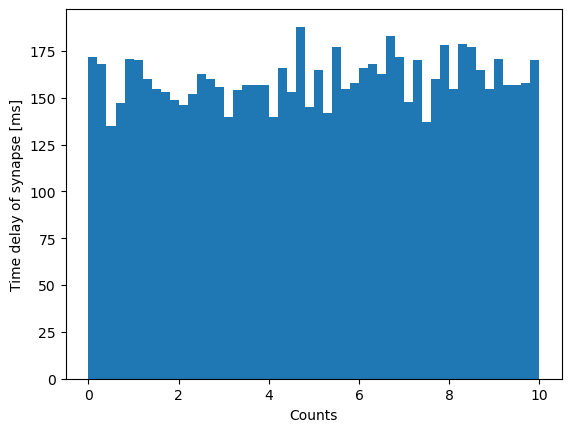

In [5]:

plt.hist(spike_delays, bins = 50)
plt.xlabel("Counts")
plt.ylabel("Time delay of synapse [ms]")